<h1> HW 2: Radar Imaging Part 3a</h1>


<h3> 3. 3D Imaging using 2D Antenna Array </h3>

This task includes two parts. Our goal is to implement radar signal processing for 3D imaging
using a 2D antenna array. You will implement two algorithms we taught in the class. 

<h5> 3.1 Algorithm 1 - Conventional Beam Forming </h5>

In this part, we will need to image the scene using Algorithm 1 we taught in class for a 2D antenna array. You will generate the 3D radar heatmap by estimating the
reflected signal power from every azimuth angles $\phi$ - elevation angles $\theta$ pair. Every azimuth
angle and elevation angle, along with the range will pinpoint a 3D voxel in the spherical
coordinates. To speed up the alogrithm, you can crop the range bins to be from 100 to 120 instead of using all 512 range bins.
The code for this task should be written in the functions *beamform_2d* defined below. We provide you
the code to load the radar data in the right format and to plot the 3D heatmap in this
file.

As results, you need to include the following in your report.
1. Generate a 3D heatmap for azimuth angle $\phi$ between 60 and 130 degrees with a resolution
of 1 degree, and elevation angle $\theta$ between 70 and 110 degrees with a resolution of 1 degrees. The
definition for $\phi$ and $\theta$ can be found in Fig. 1. Include the top view, side view, and
front view projections of the 3D heatmap in the spherical coordinates, as well as a
3D point cloud by setting a threshold on the heatmap and selecting the points with a
reflection power above this threshold. Examples of this plotting code is shown at the bottom of the file.

2. Generate the above 3D heatmaps and point clouds for all data provided. 

Write your algorithm below.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import time
import open3d as o3d
import utils 

In [20]:
# TODO ################# Change the values based on how much of the azimuth angles you want to see and the resolution ##################
# Define field of view in degrees that you want to process in theta, phi and range bins
def beamform_2d(beat_freq_data, phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_ant_pos, z_ant_pos, r_idxs, radar_params):
    """
    Performs 2D beamforming along the azimuth (horizontal) dimension, this results in a bird eye view image.
    - beat_freq_data: beat data AKA the range FFT (size: num_x_stps * num_z_stps * num TX * num RX, num ADC samples)
    - phi_s: first azimuth angle that you want to start computing 
    - phi_e: last azimuth angle that you want to compute 
    - phi_res: resolution of the azimuth angles you want to compute
    - theta_s: first elevation angle that you want to start computing 
    - theta_e: last elevation angle that you want to compute 
    - theta_res: resolution of the elevation angles you want to compute
    - x_locs: x coordinate of antenna locations
    - z_locs: z coordinate of antenna locations
    - r_idx: range bins to calculate 
    - radar_parms: radar_params if needed 

    Returns:
    - sph_pwr: beamformed result (size: n_phi, n_theta, n_range)
    - phi: array of azimuth angles 
    - theta: array of elevation angles 
    """
    # Convert angles to radians
    phi = np.radians(np.arange(phi_s, phi_e, phi_res))  # Azimuth angles (φ)
    theta = np.radians(np.arange(theta_s, theta_e, theta_res))  # Elevation angles (θ)

    num_phi = len(phi)
    num_theta = len(theta)
    num_range = len(r_idxs)

    lm = radar_params['lm']  # Wavelength (λ)

    # Initialize beamformed output
    sph_pwr = np.zeros((num_phi, num_theta, num_range), dtype=np.complex64)

    # Iterate over azimuth (φ) and elevation (θ)
    for p_idx, p in enumerate(phi):
        for t_idx, t in enumerate(theta):

            # Compute phase shifts for each antenna in x and z directions in polar coordinates
            psi_x = np.sin(t) * np.cos(p)  # Steering angle in x-axis
            psi_z = np.cos(t)  # Steering angle in z-axis

            x_phase_shift = np.exp(1j * 2 * np.pi / lm * x_ant_pos * psi_x)
            z_phase_shift = np.exp(1j * 2 * np.pi / lm * z_ant_pos * psi_z)

            # Combine phase shifts to form the full steering vector
            steering_vector = x_phase_shift * z_phase_shift

            # Iterate over range bins
            for r_idx, r in enumerate(r_idxs):

                # Extract beat frequency data for the selected range bin
                beat_freq_selected = beat_freq_data[:, :, r]  # Shape: (num_x_stps * num_z_stps, num_rx)

                # Element-wise multiplication and summation across antennas
                beamformed_signal = steering_vector * beat_freq_selected

                # Compute beamformed power
                sph_pwr[p_idx, t_idx, r_idx] = np.abs(np.sum(beamformed_signal))  # Power estimation

    return sph_pwr, phi, theta

Load data.

In [21]:
data_path = r"C:\\Users\\kresl\\Documents\\COM-304\\record\\rdc_hand2.mat"

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)

Defining antenna positions. 

In [22]:
x_ant_pos, z_pos, x_ant = utils.get_ant_pos_2d(radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['num_rx']) # this returns x position of rx, z positions of rx and tx, and x position of tx

Process raw data for BF algorthim (use all samples now).

In [23]:
# TODO: reshape raw_data and process beat frequency
# Process raw data for BF algorithm (use all samples now)
beat_freq = np.fft.fft(raw_data, axis=-1)  # Perform FFT along the last axis (ADC samples)

#beat_freq = np.fft.fftshift(beat_freq, axes=-1)  # Shift the zero frequency to the center

beat_freq = beat_freq[:, :, :]  # Crop last axis (ADC samples)
print(beat_freq.shape)

(12, 499, 512)


Define the angles and range bins to run, and run the BF algo.

In [24]:
# define the azimuth angles (horizontal FOV) that we want to look at 
c = 3e8  # Speed of light in m/s
slope = radar_params['slope']  # Given in radar_params
sample_rate = radar_params['sample_rate']  # Sampling rate from radar_params

# Convert range indices to actual distances using the formula: range = (sample_idx * c) / (2 * slope)
num_samples = radar_params['num_samples']
# r_idxs = (np.arange(100, 140, 1) * c) / (2 * slope * sample_rate) 
r_idxs = np.arange(100, 140, 1) # Change to distance rather than range bins 
phi_s, phi_e = 60, 130 
phi_res = 1
theta_s, theta_e = 70,110 
theta_res = 1

# Run your algorithm here
# TODO: input arguments that you choose
bf_output1, phi, theta = beamform_2d(beat_freq, phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_ant_pos, z_pos, r_idxs, radar_params)

Here you should plot the outputs from beamforming.

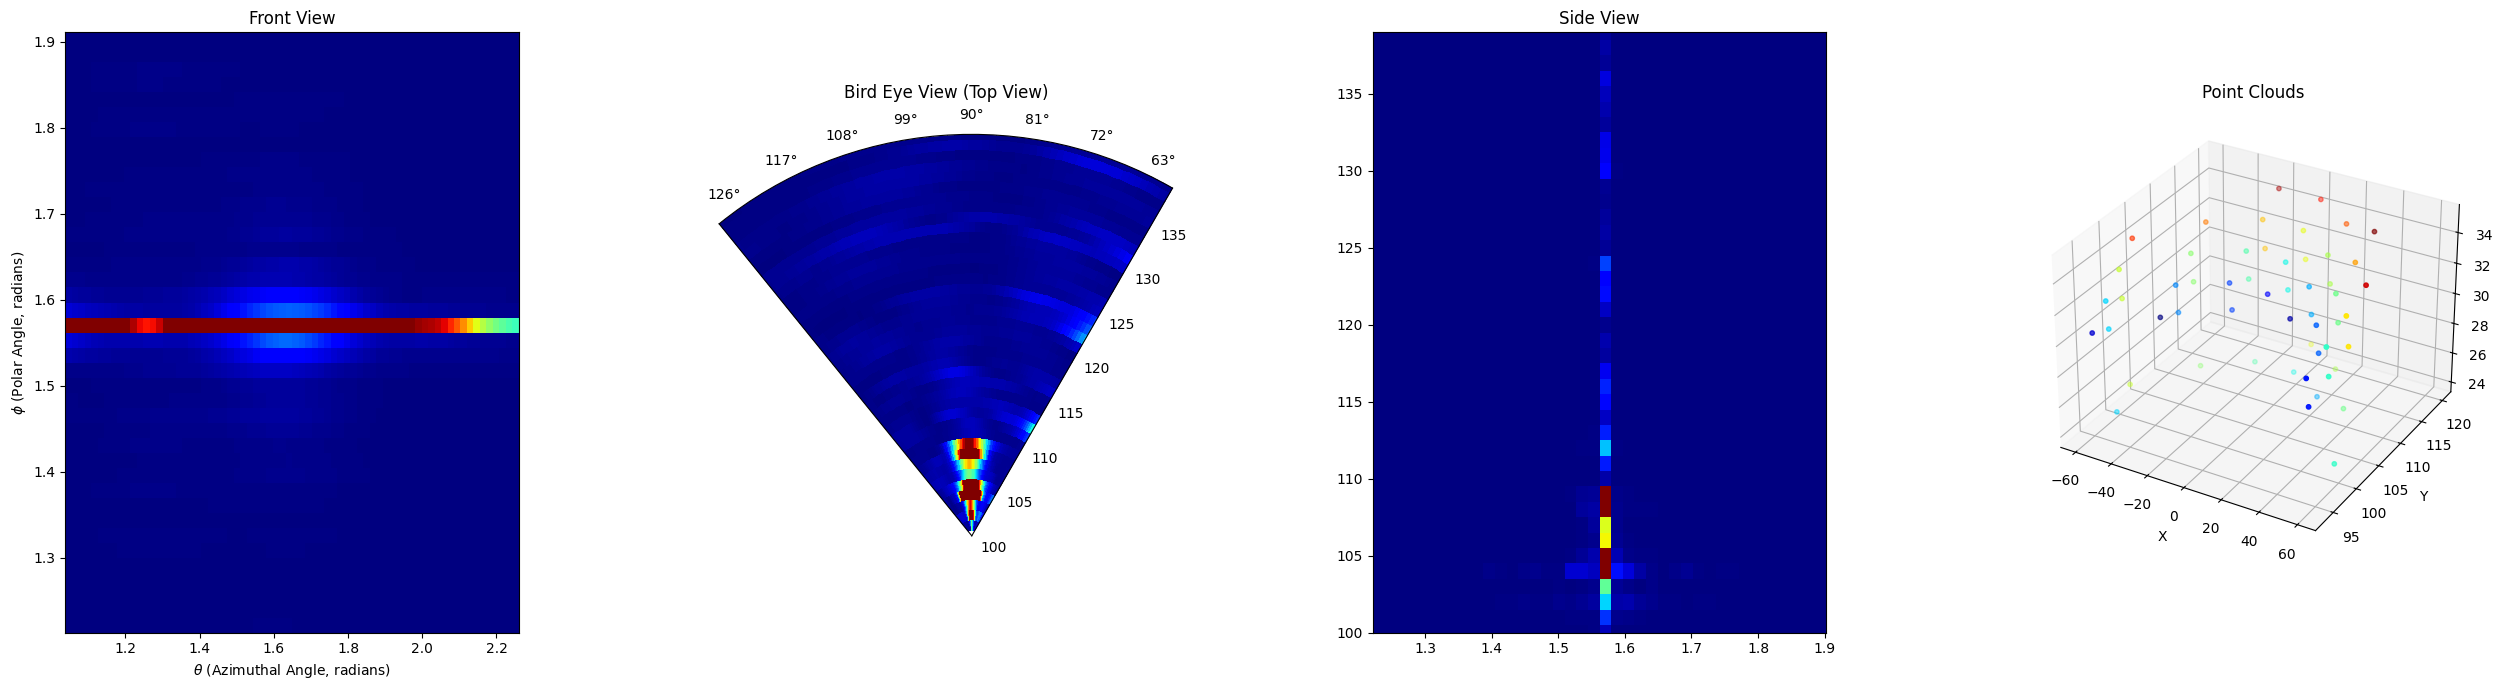

In [25]:
# Plot the output from 2D Beamforming (You can change this as you see fit)
fig = plt.figure(figsize=(25, 7))

to_plot = np.sum(abs(bf_output1),axis=-1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot**2
ax0 = fig.add_subplot(141)
utils.plot_2d_polar_heatmap(ax0, to_plot, phi, theta, vmin=0, vmax=0.1)
ax0.title.set_text('Front View')

to_plot = np.sum(abs(bf_output1),axis=1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot**2
ax1 = fig.add_subplot(142,projection = 'polar')
utils.plot_2d_heatmap(ax1, to_plot, phi, r_idxs, vmin=0, vmax=0.1)
ax1.title.set_text('Bird Eye View (Top View)')

to_plot = np.sum(abs(bf_output1),axis=0)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot**2
ax2 = fig.add_subplot(143)
utils.plot_2d_heatmap(ax2, to_plot, theta, r_idxs, vmin=0, vmax=0.1)
ax2.title.set_text('Side View')

to_plot = bf_output1
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1)))
to_plot = to_plot**2
#to_plot = np.transpose(abs(bf_output1), (2,0,1))**2
ax3 = fig.add_subplot(144, projection="3d")
utils.plot_3d_polar_heatmap(ax3, to_plot, phi, theta, r_idxs, 0.1)
ax3.title.set_text('Point Clouds')

plt.tight_layout()
plt.show()



<h1> HW 2: Radar Imaging Part 3b</h1>


<h5> 3.b Algorithm 3 - Matched Filter </h5>

In this part, we will need to image the scene using Algorithm 3 we taught in class for a 2D antenna array. You will generate the 3D radar heatmap by estimating
the reflected signal power from every voxel in the 3D cartesian coordinates (x,y,z).
The code for this task should be written in the function matched_filter_2d. We provide you
the code to load the radar data in the right format and to plot the heatmap in this
file. Though the MF output can be 3D, because of compute time, we ask that you just show a single depth slice of the scene making the output 2D.

As results, you need to include the following in your report: 
1. Generate the heatmap for all 3 scenes given
in the cartesian coordinates. The space of interest is indicated in Data Details in the google drive. The spatial resolution
should be 0.01 for x and z. Plot the front view.

2. Compare the heatmaps with the corresponding one from Task 3a, and comment on
the differences.

Notes: 
- Running matched filter code in Python can be slow. 
- And remember to check parameter clim to get reasonable heatmaps. 


Implement your matched filter algortihm below. If you would like to speed up processing time you can try to optimize code --> (eg. Numba, multiprocessing,), additionlly for debugging we recommend processing lower resolution.

Additionally, you may move away from a Jupyter Notebook for this task only if you find that optmizing the code requires this. However, please attach the plots in a PDF in addition to plotting the output in your code if you follow this path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import time
import open3d as o3d
#import helpers 
import utils

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [9]:
import numpy as np

def matched_filter_2d(raw_data_2d, x_cells, z_cells, y_fixed, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx, radar_params):
    """
    Implements Algorithm 3 for 2D matched filtering to generate a radar heatmap in Cartesian coordinates.
    
    Parameters:
    - raw_data_2d: Raw radar data (shape: (320, 369, 512))
    - x_cells: X-axis grid points (azimuth)
    - z_cells: Z-axis grid points (elevation)
    - y_fixed: Fixed depth slice
    - x_radar_tx: Transmitter x-positions (shape: (1, 80))
    - x_radar_rx: Receiver x-positions (shape: (320, 1))
    - z_radar_tx: Transmitter z-positions (shape: (1, 369))
    - z_radar_rx: Receiver z-positions (shape: (1, 369))
    - radar_params: Radar parameters (wavelength, sample rate, slope, etc.)
    
    Returns:
    - MF_output: 2D matched filter output (size: len(x_cells) x len(z_cells))
    """

    # Get radar parameters
    c = 3e8  # Speed of light (m/s)
    lm = radar_params['lm']  # Wavelength (λ)
    slope = radar_params['slope']
    sample_rate = radar_params['sample_rate']
    num_samples = radar_params['adc_samples'] 

    num_x_stps = raw_data_2d.shape[0]  # 320
    num_z_stps = raw_data_2d.shape[1]  # 369
    num_samples = raw_data_2d.shape[2]  # 512

    num_tx = x_radar_tx.shape[1]  # 80 transmitters
    num_rx_per_tx = num_x_stps // num_tx  # 4 receivers per transmitter

    # Full time vector
    t_vector = np.arange(1, num_samples + 1) / sample_rate

    # Initialize matched filter output
    MF_output = np.zeros((len(x_cells), len(z_cells)), dtype=np.complex64)

    # Reshape TX: (1, num_tx) -> (num_tx, 1) to match TX indexing
    x_radar_tx = x_radar_tx.T  # Shape: (num_tx, 1)

    # Reshape RX: (num_x_stps, 1) -> (num_tx, num_rx_per_tx) so that each TX has num_rx_per_tx RX antennas
    x_radar_rx = x_radar_rx.reshape(num_tx, num_rx_per_tx)  # Shape: (num_tx, num_rx_per_tx)

    # Broadcast z-radar positions to match TX count (num_tx locations)
    z_radar_tx = np.broadcast_to(z_radar_tx, (num_tx, num_z_stps))  # Shape: (num_tx, num_z_stps)
    z_radar_rx = np.broadcast_to(z_radar_rx, (num_tx, num_z_stps))  # Shape: (num_tx, num_z_stps)

    # Expand dimensions for broadcasting
    x_radar_rx = x_radar_rx[:, :, np.newaxis]  # Shape: (num_tx, num_rx_per_tx, 1)
    z_radar_rx = z_radar_rx[:, np.newaxis, :]  # Shape: (num_tx, 1, num_z_stps)

    # **Reshape raw data to match TX-RX pairing**
    raw_data_reshaped = raw_data_2d.reshape(num_tx, num_rx_per_tx, num_z_stps, num_samples)  # Shape: (num_tx, num_rx_per_tx, num_z_stps, num_samples)

    # Loop over voxel positions (x, z)
    for x_idx, x in enumerate(x_cells):
        for z_idx, z in enumerate(z_cells):
            print(f"z:{z_idx} / {len(z_cells)}, x:{x_idx} / {len(x_cells)}")
            # Compute distances for each TX-RX pair
            d_tx = np.sqrt((x - x_radar_tx)**2 + y_fixed**2 + (z - z_radar_tx)**2)  # Shape: (80, 369)
            d_tx = d_tx[:, np.newaxis, :]  # Expand to match RX shape: (80, 1, 369)

            d_rx = np.sqrt((x - x_radar_rx)**2 + y_fixed**2 + (z - z_radar_rx)**2)  # Shape: (80, 4, 369)

            d_total = d_tx + d_rx  # Now both are (80, 4, 369)
            tau = d_total / c  # Time delay, Shape: (80, 4, 369)

            # Compute phase shift (Negative sign for correct matched filter)
            phase_shift = np.exp(-1j * 2 * np.pi * (slope * tau[..., None] * t_vector + d_total[..., None] / lm))  # (80,4,369,512)

            # Apply matched filter using reshaped raw data
            MF_output[x_idx, z_idx] = np.sum(raw_data_reshaped * phase_shift)

    return MF_output


Load data.

In [3]:
# TODO: Put the *path* to the project folder
data_path = r"/home/tim/Documents/EPFL/COM-304-Radars/homework/given_data/data_003_.mat"

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)

Defining antenna positions.

In [4]:
x_ant_pos, z_ant_pos, x_ant = utils.get_ant_pos_2d(radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['num_rx']) # this returns x position of rx, z positions of rx and tx, and x position of tx

Process raw data for MF algorthim (use all samples now).

In [5]:
# Process raw data for MF algorithm (use all samples now)
X = raw_data.reshape((radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['adc_samples']))

Define the x,y,z voxels to calculate and the radars transmitter and receiver positions in x and z. Then run your algorithm. We recommend processing at lower resolution (eg. 0.05) or smaller portions of space for debugging.

In [ ]:
res = 0.02  # Spatial resolution = 1 cm

dataset = "data_003"  

if dataset == "data_001":
    x_max, x_min = 0.465, -0.265
    z_max, z_min = 0.175, -0.22
    y_fixed = 5.035  # Y slice for debugging

elif dataset == "data_003":
    x_max, x_min = 0.46, -0.12
    z_max, z_min = 0.25, -0.40
    y_fixed = 4.3  # Y slice for debugging

elif dataset == "data_010":
    x_max, x_min = 0.22, -0.23
    z_max, z_min = 0.24, -0.185
    y_fixed = 4.45  # Y slice for debugging

# Compute number of voxels in x and z based on limits
x_cells = np.arange(x_min, x_max, res)  # X-axis grid points
z_cells = np.arange(z_min, z_max, res)  # Z-axis grid points
y_cells = 1  # 1 slice depth for debugging

# Define radar transmitter and receiver positions
x_radar_tx = x_ant  # Correct: x_ant for TX
x_radar_rx = x_ant_pos  # Correct: x_ant_pos for RX
z_radar_tx = z_ant_pos  # z_ant_pos for TX
z_radar_rx = z_ant_pos  # z_ant_pos for RX

print(f"Using dataset: {dataset}")
print(f"x range: {x_min} to {x_max}, num_x_cells: {len(x_cells)}")
print(f"z range: {z_min} to {z_max}, num_z_cells: {len(z_cells)}")
print(f"y_fixed (depth slice): {y_fixed}")

# Run matched filter algorithm
MF_output = matched_filter_2d(X, x_cells, z_cells, y_fixed, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx, radar_params)


Using dataset: data_003
x range: -0.12 to 0.46, num_x_cells: 30
z range: -0.4 to 0.25, num_z_cells: 33
y_fixed (depth slice): 4.3
z:0 / 33, x:0 / 30
z:1 / 33, x:0 / 30
z:2 / 33, x:0 / 30
z:3 / 33, x:0 / 30
z:4 / 33, x:0 / 30
z:5 / 33, x:0 / 30
z:6 / 33, x:0 / 30
z:7 / 33, x:0 / 30
z:8 / 33, x:0 / 30
z:9 / 33, x:0 / 30
z:10 / 33, x:0 / 30
z:11 / 33, x:0 / 30
z:12 / 33, x:0 / 30
z:13 / 33, x:0 / 30
z:14 / 33, x:0 / 30
z:15 / 33, x:0 / 30
z:16 / 33, x:0 / 30
z:17 / 33, x:0 / 30
z:18 / 33, x:0 / 30
z:19 / 33, x:0 / 30
z:20 / 33, x:0 / 30
z:21 / 33, x:0 / 30
z:22 / 33, x:0 / 30
z:23 / 33, x:0 / 30
z:24 / 33, x:0 / 30
z:25 / 33, x:0 / 30
z:26 / 33, x:0 / 30
z:27 / 33, x:0 / 30
z:28 / 33, x:0 / 30
z:29 / 33, x:0 / 30
z:30 / 33, x:0 / 30
z:31 / 33, x:0 / 30
z:32 / 33, x:0 / 30
z:0 / 33, x:1 / 30
z:1 / 33, x:1 / 30
z:2 / 33, x:1 / 30
z:3 / 33, x:1 / 30
z:4 / 33, x:1 / 30
z:5 / 33, x:1 / 30
z:6 / 33, x:1 / 30
z:7 / 33, x:1 / 30
z:8 / 33, x:1 / 30
z:9 / 33, x:1 / 30
z:10 / 33, x:1 / 30
z:11 / 33,

Plot your outputs below.

MF_output shape: (12, 13)
to_plot shape: (12, 13)


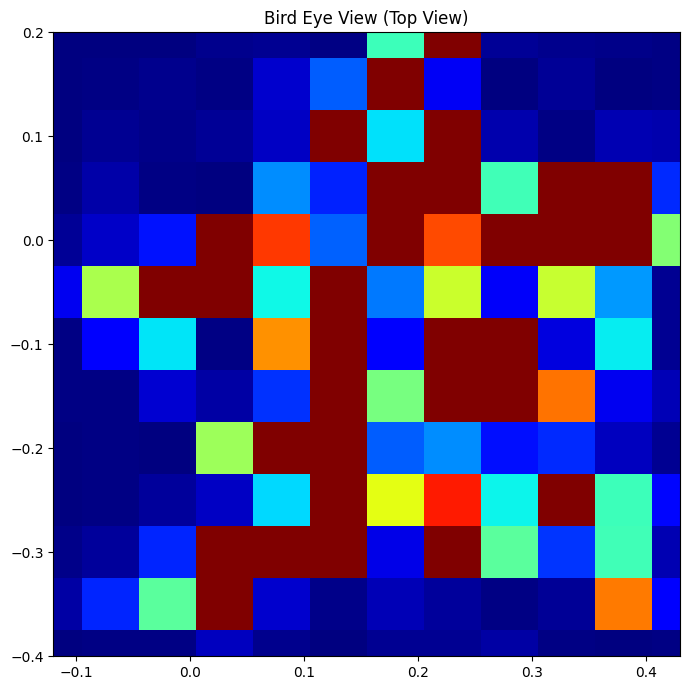

In [55]:
# Plot the output from MF (You can change this as you see fit (this will just plot the front of the object as we are not processing the entire heatmap)

fig = plt.figure(figsize=(7, 7))
to_plot = abs(MF_output) # for 2D MF_output (debugging)
#to_plot = np.sum(abs(MF_output), axis=-1) # for 3D MF_output
print(f"MF_output shape: {MF_output.shape}")
print(f"to_plot shape: {to_plot.shape}")
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot**2
ax0 = fig.add_subplot(111)


utils.plot_2d_heatmap(ax0, to_plot, x_cells, z_cells, vmin=0, vmax=0.1)
#utils.plot_2d_heatmap(ax0, to_plot, num_x_cells, num_z_cells, vmin=0, vmax=0.1)
ax0.title.set_text('Bird Eye View (Top View)')

plt.tight_layout()
plt.show()
